In [432]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import math
import pickle
import os
from scipy.optimize import minimize
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import importlib
from scipy.interpolate import UnivariateSpline
from scipy import integrate
from scipy.optimize import root_scalar

import halo_and_cluster_MF as hcmf
import useful_functions as uf

cosmo = Planck18


In [433]:
path_eRASS1 = '../DESI_eRass/eRass_Bulbul_2024.fit' #la première table est la table eRosita de départ, enrichie avec des informations d'association avec SDSS-Wen
table_eRASS1 = uf.fits_to_dataframe(path_eRASS1)

In [434]:
## eRASS1
bornes_z_eRASS1 = [0.03,1.32] 
angular_area_eRASS1_deg2 = 13116 # Surface couverte par eRASS1/SDSS/unWISE en degrés carrés
volume_eRASS1 = uf.Volume_survey(angular_area_eRASS1_deg2,bornes_z_eRASS1)

# Calcul $\frac{dn}{dlog_{10}(M_{500})}(M_{500})$

In [435]:
from matplotlib.colors import LinearSegmentedColormap
colors = ["blue", "cyan", "green", "darkorange", "orangered","lightcoral"]


In [436]:
range_log10_M_Msun = np.linspace(12.5,15.5,1000) # log10(M500/Msun)
range_z = np.linspace(0.1,2.1,5)

CMF_values_z = []

for z in range_z:
    CMF_values_z.append(hcmf.CMF_Bocquet_2016_log10(10**(range_log10_M_Msun), z))

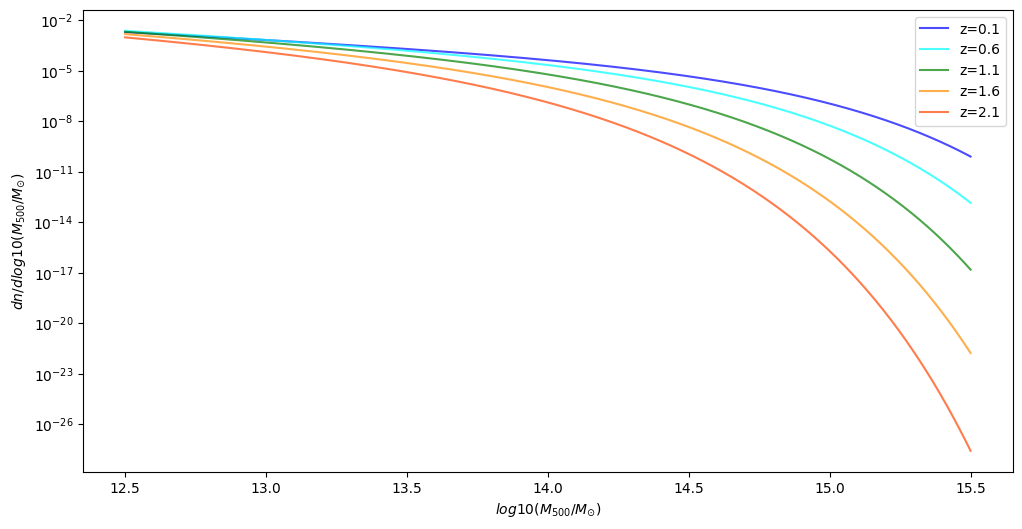

In [437]:
plt.figure(figsize=(12, 6))

for i,ClxF_values in enumerate(CMF_values_z):
    plt.plot(range_log10_M_Msun, CMF_values_z[i], color=colors[i], label = f'z={range_z[i]}' ,alpha=0.7)
    plt.yscale('log')
    plt.xlabel(r'$log10(M_{500}/M_{\odot}$)')
    plt.ylabel(r'$dn / dlog10(M_{500}/M_{\odot})$')

    

plt.legend()

plt.show()

# Définition fonctions utiles
On va les tester pour les modifier

In [438]:
# Fonctions de base dans uf :

def M_from_Lx(Lx, z):
    # section 2.3 Maughan et al. 2013
    # Lx : Cluster Luminosity in erg/s, between 0.2 and 2.3 keV
    # z : redshift

    # On commence par passer de Lx (compris entre 0.2 et 2.3 kev) à L_Maughan (correspond à l'entièreté du rayonnement Bremsstrahlung)
    coeff_Lx_L = 1/3
    
    #a_coeff = 0.093 ; b_coeff = 0.254
    #coeff_Lx_L = (a_coeff * z + b_coeff) # → issu de l'optimisation (voir test_optim_BLM.py)

    L_Maughan = Lx * (1/coeff_Lx_L)


    # Ensuite on utilise la relation d'échelle de Maughan et al. 2013 pour passer de L_Maughan à M500
    # 1) Valeurs : Table 5 Maughan et al. 2018
    A_LM = 0.97 ; A_LM_minus = A_LM - 0.08 ; A_LM_max = A_LM + 0.08
    B_LM = 1.64 ; B_LM_minus = B_LM - 0.09 ; B_LM_max = B_LM + 0.09
    

    # 2) Valeurs : For self-similar clusters in virial equilibrium :
    #B_LM = 4/3
    gamma_LM = 7/3

    # 3) Valeurs issu de l'optim (voir test_optim_BLM.py):
    #B_LM = 1.476
    #a = -0.495 ; b = 1.539
    #B_LM = a * z + b


    L_0 = 5*1e44 # erg/s
    M_0 = 5*1e14 # M_sun
    E_z = cosmo.efunc(z)  # E(z) = H(z)/H0

    M = M_0 * ((L_Maughan/L_0) / (A_LM * (E_z)**gamma_LM))**(1/B_LM)

    return M

def CLxF_eRASS_Bocquet_2016(Lx , z):
    # Cluster X-ray luminosity function adapted for eRASS1 using Maughan et al. 2013 and Bocquet et al. 2016 CMF
    # Lx : Cluster Luminosity in erg/s, between 0.2 and 2.3 keV
    # z : redshift

    # Renvoie (dn/dlog10(Lx))(Lx(M500))

    # On commence par calculer (dn/dlog10(M500))(M500) isssu de Bocquet et al. 2016
    M500 = M_from_Lx(Lx,z) #→ utilise Maughan et al. 2013
    dn_dlog10M500 = hcmf.CMF_Bocquet_2016_log10(M500, z)

    # On calcule l'élément différentiel
    # 1) Valeurs : Table 5 Maughan et al. 2018
    B_LM = 1.64 ; B_LM_minus = B_LM - 0.09 ; B_LM_max = B_LM + 0.09

    # 2)
    #a = -0.495 ; b = 1.539
    #B_LM = a * z + b

    dlog10M500_dlog10Lx = 1/B_LM

    # On a notre résultat final :
    dn_dlog10Lx = dn_dlog10M500 * dlog10M500_dlog10Lx

    return dn_dlog10Lx

In [439]:
# fonctions expérimentales :

def CMF_inCLxF_eRASS_Bocquet_2016(Lx,z):
    # Partie de CLxF_eRASS_Bocquet_2016
    # Lx : Cluster Luminosity in erg/s, between 0.2 and 2.3 keV
    # z : redshift

    # Renvoie (dn/dlog10(Lx))(Lx(M500))

    # On commence par calculer (dn/dlog10(M500))(M500) isssu de Bocquet et al. 2016
    M500 = M_from_Lx(Lx,z) #→ utilise Maughan et al. 2013
    dn_dlog10M500 = hcmf.CMF_Bocquet_2016_log10(M500, z)

    return dn_dlog10M500


def B_LM(z):
    # Fonction pour calculer B_LM en fonction du redshift z
    a = -0.495
    b = 1.539
    B_LM = a * z + b
    return B_LM

def Lx_from_M_Maughan(M, z):
    # section 2.3 Maughan et al. 2018
    # M : Total mass of the cluster (M500 ?) : Msun
    # z : redshift

    # 1) Valeurs : Table 5 Maughan et al. 2018
    A_LM = 0.97 ; A_LM_minus = A_LM - 0.08 ; A_LM_max = A_LM + 0.08
    B_LM = 1.64 ; B_LM_minus = B_LM - 0.09 ; B_LM_max = B_LM + 0.09

    # 2) Valeurs : For self-similar clusters in virial equilibrium :
    #B_LM = 4/3
    gamma_LM = 7/3

    # 3) Valeurs issu de l'optim (voir test_optim_BLM.py):
    #B_LM = 1.476
    #a = -0.495 ; b = 1.539
    #B_LM = a * z + b

    L_0 = 5*1e44 # erg/s
    M_0 = 5*1e14 # M_sun
    E_z = cosmo.efunc(z)  # E(z) = H(z)/H0

    L = L_0 * A_LM * ((E_z)**gamma_LM) * ((M/M_0)**B_LM)

    #On ajoute le coeff pour passer dans la bande de 0.2-2.3 kev
    coeff_Lx_L = 1/3
    #a_coeff = 0.093 ; b_coeff = 0.254
    #coeff_Lx_L = (a_coeff * z + b_coeff) # → issu de l'optimisation (voir test_optim_BLM.py)
    

    Lx = L * coeff_Lx_L

    return Lx # L en erg/s ; dans la bande 0.2-2.3 kev


def M_from_Lx_random_power_law(Lx,z,alpha):
    # Lx : Cluster Luminosity in erg/s, between 0.2 and 2.3 keV
    # z : redshift
    # alpha : exposant de la loi de puissance

    # On commence par calculer M500 à partir de Lx
    # On utilise une loi de puissance aléatoire pour cela
    L_0 = 5*1e44 # erg/s
    M_0 = 5*1e14 # M_sun

    M500 = (Lx / L_0)**(alpha) * M_0 * cosmo.efunc(z)**2  # Conversion en M_sun

    return M500


# Calculs valeurs

In [440]:
# Données
LX_eRASS1 = np.array(table_eRASS1['L500']) # 0.2-2.3keV luminosity within R500 at zlambda (10^35 W → 10^42 erg.s^-1)
LX_eRASS1 = LX_eRASS1 * 1e42 # W → erg.s^-1
LX_eRASS1 = LX_eRASS1[(LX_eRASS1 > 0)] # On ne garde que les valeurs stritement positives de luminosité
log10_LX_eRASS1 = np.log10(LX_eRASS1) # log10(LX_eRASS1) in erg.s^-1
ln_LX_eRASS1 = np.log(LX_eRASS1)

bin_centers_LX_eRASS1_log10, counts_LX_eRASS1_log10, bin_width_LX_eRASS_log10, n_LX_eRASS1_log10 = uf.compute_histogram_density(log10_LX_eRASS1,bins=100,volume=volume_eRASS1)
print("Bin width for log10(LX eRASS1):", bin_width_LX_eRASS_log10)

Bin width for log10(LX eRASS1): 0.044988633799981415


In [441]:
#Théorie 
#range_Lx = np.linspace(1e-3 * 1e42,3600 * 1e42,10000) # 10^42 erg.s^-1
range_z = np.arange(0.1, 1.4, 0.3) 

ClxF_values_z = []
for z in range_z:
    ClxF_values_z.append(hcmf.CLxF_eRASS_Bocquet_2016(10**(bin_centers_LX_eRASS1_log10), z))
    

In [442]:
# Test (dn/dlog10(M500))(M500(Lx))

CMF_inCLxF_eRASS_Bocquet_2016_values = []

for z in range_z:
    CMF_inCLxF_eRASS_Bocquet_2016_values.append(CMF_inCLxF_eRASS_Bocquet_2016(10**bin_centers_LX_eRASS1_log10, z))


In [443]:
# Test (dn/dlog10(M500))(M500) * (1/B_LM)

CMF_Bocquet_2016_with_B_LM = []

for z in range_z:
    CMF_Bocquet_2016_with_B_LM.append(hcmf.CMF_Bocquet_2016_log10(10**(range_log10_M_Msun),z) * (1/B_LM(z)))


In [444]:
range_M500_from_LX = []

for z in range_z:
    range_M500_from_LX.append(M_from_Lx(10**bin_centers_LX_eRASS1_log10, z))
    print('For z =', z, 'M500 min  =', np.log10(np.min(range_M500_from_LX[-1])), 'M500 max =', np.log10(np.max(range_M500_from_LX[-1])), '\n')

For z = 0.1 M500 min  = 12.760620092631157 M500 max = 15.476397376898332 

For z = 0.4 M500 min  = 12.656960340758635 M500 max = 15.37273762502581 

For z = 0.7000000000000001 M500 min  = 12.54482287267116 M500 max = 15.260600156938334 

For z = 1.0000000000000002 M500 min  = 12.43361590746145 M500 max = 15.149393191728624 

For z = 1.3000000000000003 M500 min  = 12.327883041216642 M500 max = 15.043660325483817 



In [445]:
range_Lx_from_M500 = []

for z in range_z:
    range_Lx_from_M500.append(Lx_from_M_Maughan(10**range_log10_M_Msun, z))

In [446]:
range_M500_from_LX_test = []

power = 1.1 # Exposant de la loi de puissance pour M_from_Lx_random_power_law

for z in range_z:
    range_M500_from_LX_test.append(M_from_Lx_random_power_law(10**bin_centers_LX_eRASS1_log10, z,alpha = power))

# Tracés

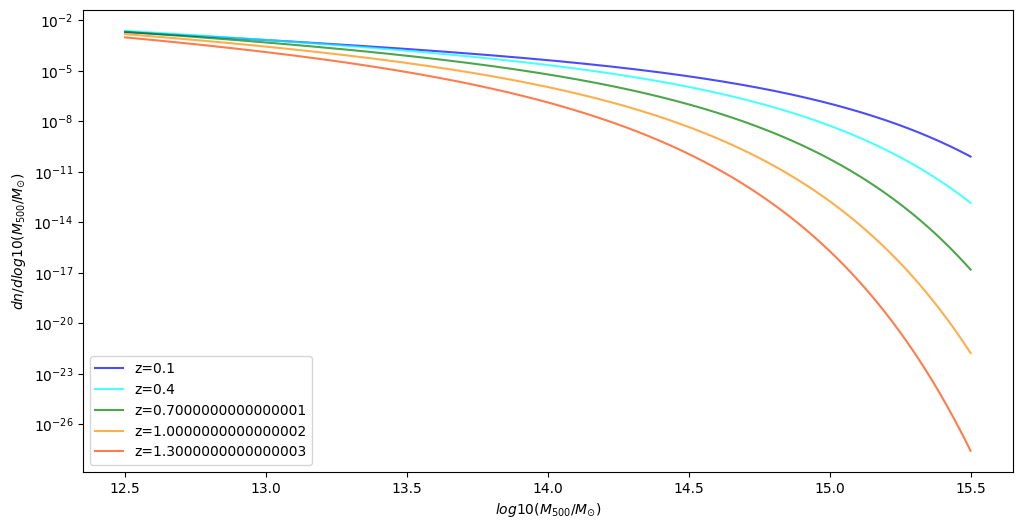

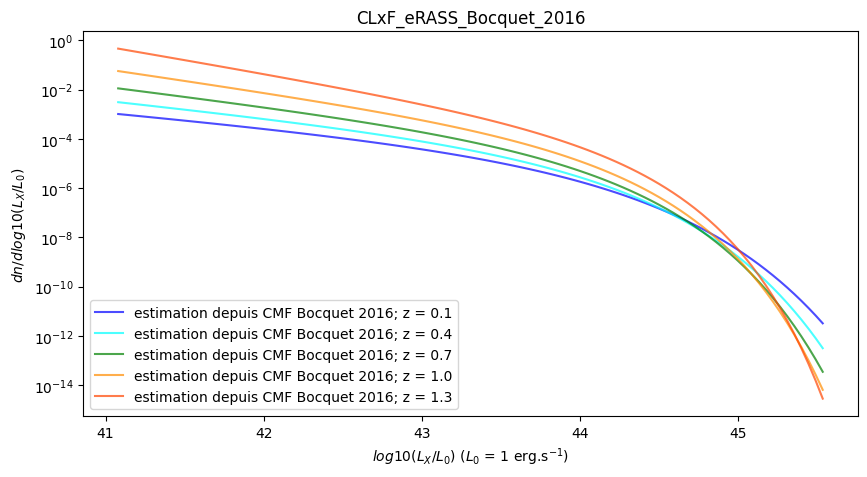

In [447]:
# Que la fonction de masse

plt.figure(figsize=(12, 6))

for i,ClxF_values in enumerate(CMF_values_z):
    plt.plot(range_log10_M_Msun, CMF_values_z[i], color=colors[i], label = f'z={range_z[i]}' ,alpha=0.7)
    plt.yscale('log')
    plt.xlabel(r'$log10(M_{500}/M_{\odot}$)')
    plt.ylabel(r'$dn / dlog10(M_{500}/M_{\odot})$')

    

plt.legend()



# A comparer avec la théorie de la fonction de luminosité ! → besoin d'une relation d'échelle adaptée à eRASS1
plt.figure(figsize=(10, 5))


for i,ClxF_values in enumerate(ClxF_values_z):
    plt.plot(bin_centers_LX_eRASS1_log10, ClxF_values, color=colors[i], label=f'estimation depuis CMF Bocquet 2016; z = {np.round(range_z[i], 2)}', alpha=0.7)
    plt.xlabel(r'$log10(L_{X}/L_0)$ ($L_0$ = 1 erg.s$^{-1}$)')
    plt.ylabel(r'$dn / dlog10(L_{X}/L_0)$ ')
    plt.yscale('log')

plt.title("CLxF_eRASS_Bocquet_2016")   

plt.legend()

plt.show()

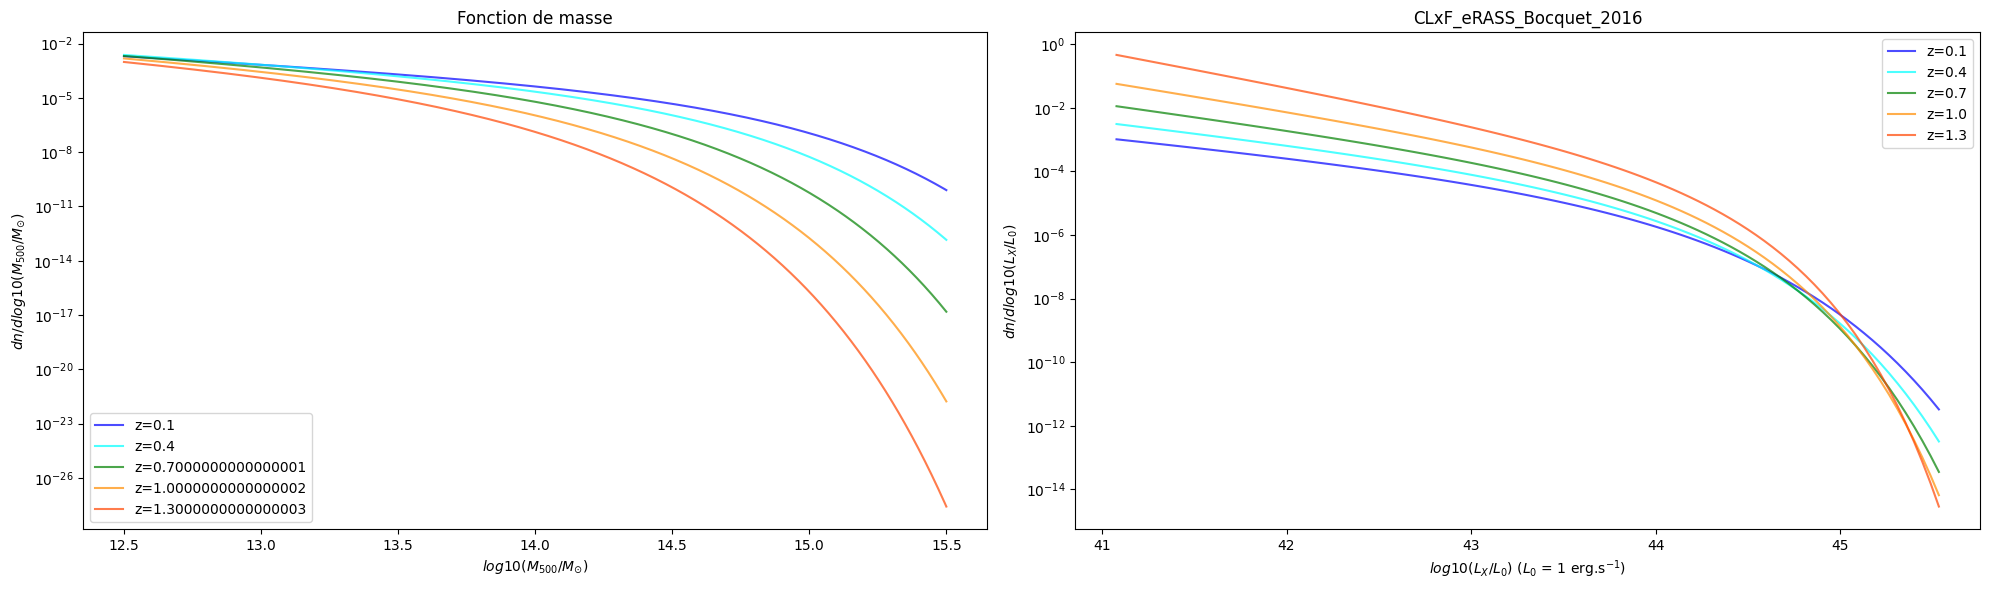

In [448]:
fig, axs = plt.subplots(1, 2, figsize=(20, 6))

# Fonction de masse
for i, ClxF_values in enumerate(CMF_values_z):
    axs[0].plot(range_log10_M_Msun, ClxF_values, color=colors[i], label=f'z={range_z[i]}', alpha=0.7)
axs[0].set_yscale('log')
axs[0].set_xlabel(r'$log10(M_{500}/M_{\odot}$)')
axs[0].set_ylabel(r'$dn / dlog10(M_{500}/M_{\odot})$')
axs[0].legend()
axs[0].set_title("Fonction de masse")

# Fonction de luminosité
for i, ClxF_values in enumerate(ClxF_values_z):
    axs[1].plot(bin_centers_LX_eRASS1_log10, ClxF_values, color=colors[i], label=f'z={np.round(range_z[i], 2)}', alpha=0.7)
axs[1].set_xlabel(r'$log10(L_{X}/L_0)$ ($L_0$ = 1 erg.s$^{-1}$)')
axs[1].set_ylabel(r'$dn / dlog10(L_{X}/L_0)$ ')
axs[1].set_yscale('log')
axs[1].legend()
axs[1].set_title("CLxF_eRASS_Bocquet_2016")

plt.tight_layout()
plt.show()


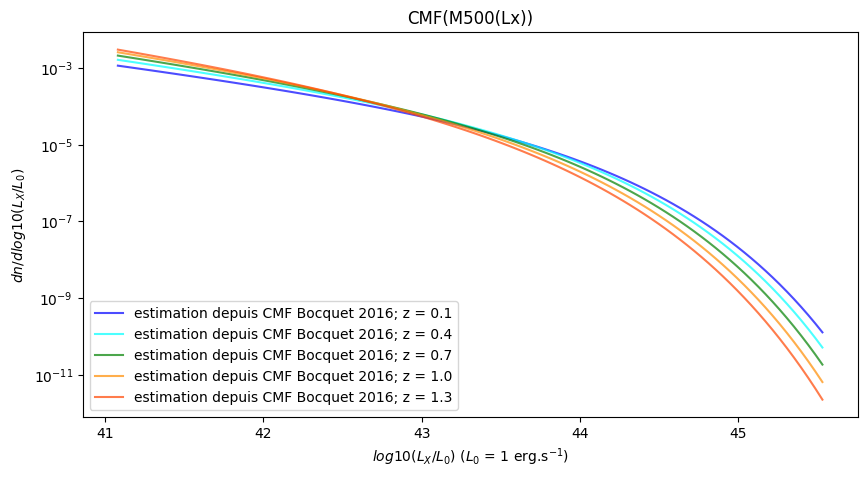

In [449]:
plt.figure(figsize=(10, 5))


for i,ClxF_values in enumerate(ClxF_values_z):
    plt.plot(bin_centers_LX_eRASS1_log10, CMF_inCLxF_eRASS_Bocquet_2016_values[i], color=colors[i], label=f'estimation depuis CMF Bocquet 2016; z = {np.round(range_z[i], 2)}', alpha=0.7)
    plt.xlabel(r'$log10(L_{X}/L_0)$ ($L_0$ = 1 erg.s$^{-1}$)')
    plt.ylabel(r'$dn / dlog10(L_{X}/L_0)$ ')
    plt.yscale('log')

plt.title("CMF(M500(Lx))")

plt.legend()

plt.show()

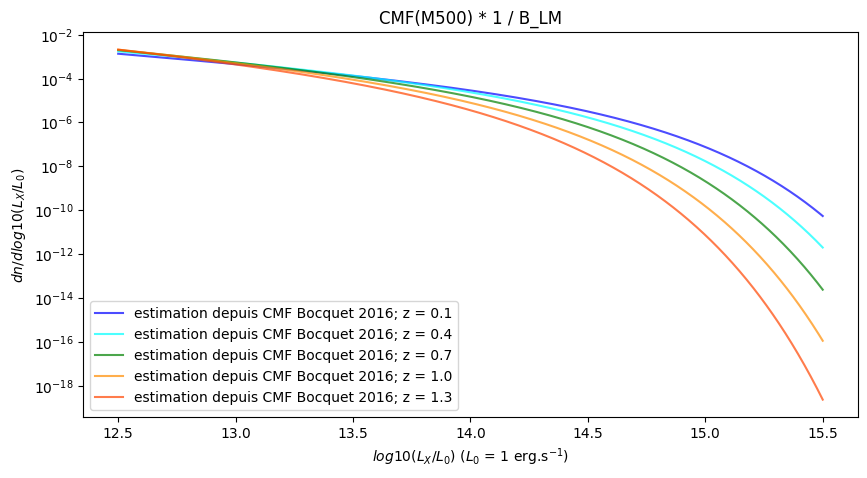

In [450]:
plt.figure(figsize=(10, 5))


for i,ClxF_values in enumerate(ClxF_values_z):
    plt.plot(range_log10_M_Msun, CMF_Bocquet_2016_with_B_LM[i], color=colors[i], label=f'estimation depuis CMF Bocquet 2016; z = {np.round(range_z[i], 2)}', alpha=0.7)
    plt.xlabel(r'$log10(L_{X}/L_0)$ ($L_0$ = 1 erg.s$^{-1}$)')
    plt.ylabel(r'$dn / dlog10(L_{X}/L_0)$ ')
    plt.yscale('log')

plt.title("CMF(M500) * 1 / B_LM")

plt.legend()

plt.show()

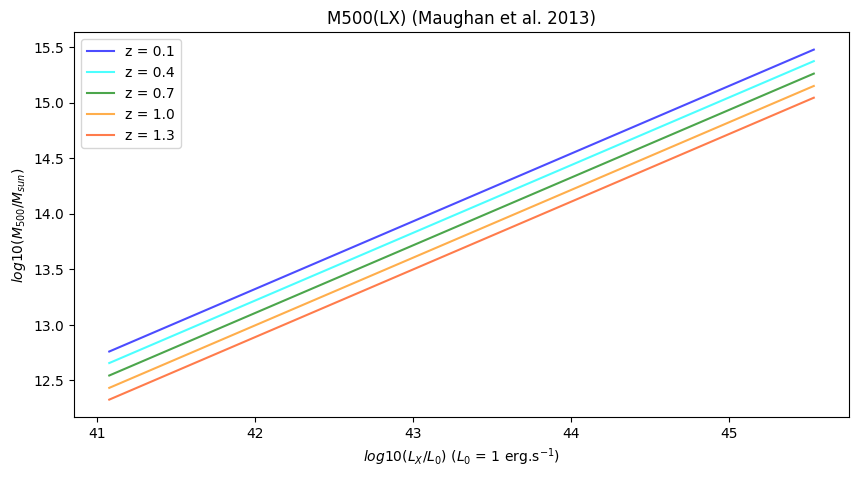

In [451]:
plt.figure(figsize=(10, 5))


for i,M500_range in enumerate(range_M500_from_LX):
    plt.plot(bin_centers_LX_eRASS1_log10, np.log10(M500_range), color=colors[i], label=f'z = {np.round(range_z[i], 2)}', alpha=0.7)
    plt.xlabel(r'$log10(L_{X}/L_0)$ ($L_0$ = 1 erg.s$^{-1}$)')
    plt.ylabel(r'$log10(M_{500}/M_{sun})$ ')

plt.title("M500(LX) (Maughan et al. 2013)")

plt.legend()

plt.show()

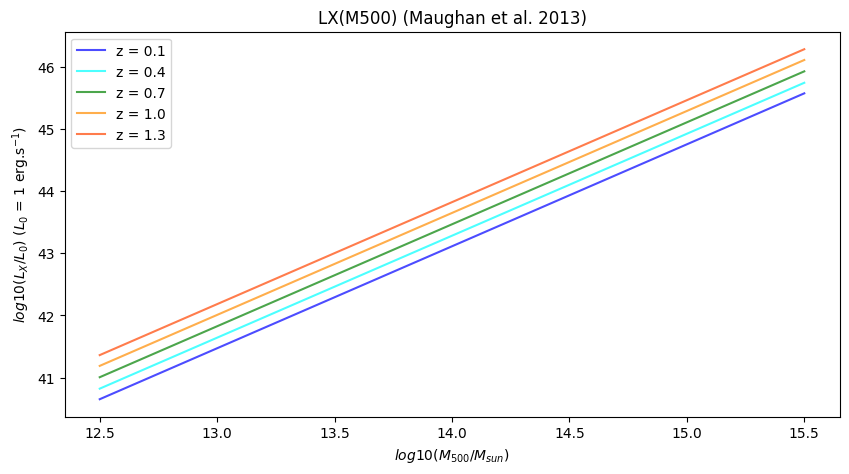

In [452]:
plt.figure(figsize=(10, 5))


for i,Lx_range in enumerate(range_Lx_from_M500):
    plt.plot(range_log10_M_Msun, np.log10(Lx_range), color=colors[i], label=f'z = {np.round(range_z[i], 2)}', alpha=0.7)
    plt.ylabel(r'$log10(L_{X}/L_0)$ ($L_0$ = 1 erg.s$^{-1}$)')
    plt.xlabel(r'$log10(M_{500}/M_{sun})$ ')

plt.title("LX(M500) (Maughan et al. 2013)")

plt.legend()

plt.show()

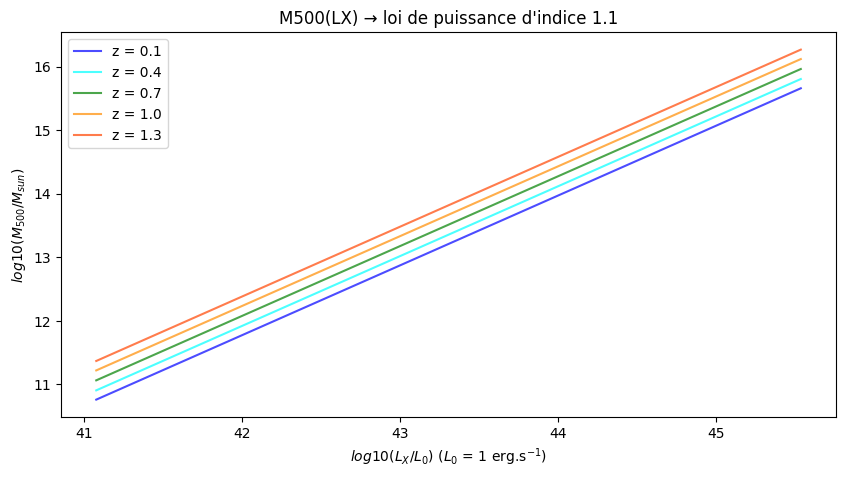

In [453]:
plt.figure(figsize=(10, 5))


for i,M500_range in enumerate(range_M500_from_LX_test):
    plt.plot(bin_centers_LX_eRASS1_log10, np.log10(M500_range), color=colors[i], label=f'z = {np.round(range_z[i], 2)}', alpha=0.7)
    plt.xlabel(r'$log10(L_{X}/L_0)$ ($L_0$ = 1 erg.s$^{-1}$)')
    plt.ylabel(r'$log10(M_{500}/M_{sun})$ ')

plt.title(f"M500(LX) → loi de puissance d'indice {power}")

plt.legend()
plt.show()